# OVR Logistic Regression with Thresholding

This notebook builds a threshold-based one-vs-rest logistic regression benchmark for ACC skill tagging.

What this notebook does:
- loads ACC job, course, and skill embeddings from `../embedding/acc`
- joins each embedded entity to its ground-truth `extracted_skills` label from the CSVs
- builds two dataset variants: `jobs_only` and `jobs_plus_courses`
- trains one logistic regression model per skill on the train split
- tunes thresholds on the validation split only
- selects the final configuration using validation metrics
- reports the final locked metrics on the held-out test split

This is important because we want the final numbers to reflect real held-out performance rather than validation-tuned performance.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

EMBEDDINGS_PATH = Path("../embedding/acc")
JOB_LABEL_CSV = Path("../data/acc/audit_tax_accounting_jobs.csv")
COURSE_LABEL_CSV = Path("../data/acc/acc_courses.csv")
SKILLS_EMBEDDINGS_PATH = EMBEDDINGS_PATH / "acc_skills_embeddings.jsonl"
JOBS_EMBEDDINGS_PATH = EMBEDDINGS_PATH / "acc_jobs_embeddings.jsonl"
COURSES_EMBEDDINGS_PATH = EMBEDDINGS_PATH / "acc_courses_embeddings.jsonl"

skills_embeddings = pd.read_json(SKILLS_EMBEDDINGS_PATH, lines=True)
jobs_embeddings = pd.read_json(JOBS_EMBEDDINGS_PATH, lines=True)
courses_embeddings = pd.read_json(COURSES_EMBEDDINGS_PATH, lines=True)
job_labels = pd.read_csv(JOB_LABEL_CSV)
course_labels = pd.read_csv(COURSE_LABEL_CSV)

print("Embedding splits:")
print(jobs_embeddings["split"].value_counts().sort_index().rename("jobs"))
print()
print(courses_embeddings["split"].value_counts().sort_index().rename("courses"))
print()
print(f"num_skills: {len(skills_embeddings)}")


Embedding splits:
split
test     20
train    59
val      19
Name: jobs, dtype: int64

split
test     13
train    38
val      13
Name: courses, dtype: int64

num_skills: 229


## Helper Functions

These helpers do the repetitive setup work:
- convert `extracted_skills` text into Python lists
- join embeddings to labels
- build binary label matrices
- train one logistic regression per skill
- tune thresholds and compute metrics

Keeping them here makes the actual experiment cells shorter and easier to read.


In [ ]:
def parse_skill_list(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    return [skill.strip() for skill in str(value).split("|") if skill.strip()]


def attach_actual_skill_lists(df, labels_df, left_key, right_key):
    merged = df.merge(
        labels_df,
        left_on=left_key,
        right_on=right_key,
        how="left",
        suffixes=("_embed", "_label"),
    )

    missing_mask = merged["extracted_skills"].isna()
    dropped_ids = merged.loc[missing_mask, left_key].tolist()
    if dropped_ids:
        print(f"Dropping {len(dropped_ids)} unlabeled rows for {left_key}: {dropped_ids}")
        merged = merged.loc[~missing_mask].copy()

    merged["actual_skill_lists"] = merged["extracted_skills"].apply(parse_skill_list)
    merged["display_title"] = merged["title_label"] if "title_label" in merged.columns else merged["title"]
    merged["entity_id"] = merged[left_key]

    return merged[["entity_type", "entity_id", "display_title", "embedding", "actual_skill_lists"]].copy()


def build_indicator_matrix(skill_lists, skill_names):
    skill_to_idx = {skill: idx for idx, skill in enumerate(skill_names)}
    indicator = np.zeros((len(skill_lists), len(skill_names)), dtype=np.uint8)

    for row_idx, skills in enumerate(skill_lists):
        for skill in skills:
            if skill in skill_to_idx:
                indicator[row_idx, skill_to_idx[skill]] = 1

    return indicator


def build_dataset(train_df, val_df, test_df, skill_names):
    X_train = np.vstack(train_df["embedding"].to_numpy()).astype(np.float32)
    X_val = np.vstack(val_df["embedding"].to_numpy()).astype(np.float32)
    X_test = np.vstack(test_df["embedding"].to_numpy()).astype(np.float32)

    Y_train = build_indicator_matrix(train_df["actual_skill_lists"].tolist(), skill_names)
    Y_val = build_indicator_matrix(val_df["actual_skill_lists"].tolist(), skill_names)
    Y_test = build_indicator_matrix(test_df["actual_skill_lists"].tolist(), skill_names)

    return X_train, X_val, X_test, Y_train, Y_val, Y_test


def fit_ovr_probabilities(X_train, Y_train, X_val, X_test, skill_names):
    # Store predicted probabilities for each split.
    train_proba = np.zeros((X_train.shape[0], len(skill_names)), dtype=np.float32)
    val_proba = np.zeros((X_val.shape[0], len(skill_names)), dtype=np.float32)
    test_proba = np.zeros((X_test.shape[0], len(skill_names)), dtype=np.float32)

    # Track which skills had a fitted logistic regression model.
    fitted_mask = np.zeros(len(skill_names), dtype=bool)
    fitted_models = [None] * len(skill_names)
    skipped_skills = []

    # Train one binary classifier per skill.
    for j, skill_name in enumerate(skill_names):
        y_train_j = Y_train[:, j]
        unique_classes = np.unique(y_train_j)

        # LogisticRegression requires at least two classes.
        # If the skill is constant in training data, use that
        # constant class as the fallback probability.
        if len(unique_classes) < 2:
            constant_proba = float(unique_classes[0])
            train_proba[:, j] = constant_proba
            val_proba[:, j] = constant_proba
            test_proba[:, j] = constant_proba
            skipped_skills.append(skill_name)
            continue

        # Standard OvR Binary Classifier
        model = LogisticRegression(
            class_weight="balanced", # Vital for rare skills
            max_iter=2000,
            random_state=42
        )
        model.fit(X_train, y_train_j)

        # Save the probability of class 1 for each split.
        train_proba[:, j] = model.predict_proba(X_train)[:, 1]
        val_proba[:, j] = model.predict_proba(X_val)[:, 1]
        test_proba[:, j] = model.predict_proba(X_test)[:, 1]
        
        fitted_mask[j] = True
        fitted_models[j] = model

    return train_proba, val_proba, test_proba, fitted_mask, fitted_models, skipped_skills


def micro_metrics(y_true, y_pred):
    tp = np.logical_and(y_pred == 1, y_true == 1).sum()
    fp = np.logical_and(y_pred == 1, y_true == 0).sum()
    fn = np.logical_and(y_pred == 0, y_true == 1).sum()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0

    return precision, recall, f1


def macro_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    return precision, recall, f1


def tune_global_threshold(y_true, y_score):
    # Try every unique score as a possible threshold.
    candidate_thresholds = np.unique(y_score)

    # Add a threshold above 1 so the "predict nothing" case is also checked.
    candidate_thresholds = np.r_[candidate_thresholds, 1.0 + 1e-9]

    best_threshold = 0.5
    best_candidate = None

    for threshold in candidate_thresholds:
        # Convert probabilities into binary predictions.
        y_pred = (y_score >= threshold).astype(np.uint8)
        precision, recall, f1 = micro_metrics(y_true, y_pred)

        # Rank by F1 first, then recall, then prefer smaller thresholds.
        candidate = (f1, recall, -threshold)

        if best_candidate is None or candidate > best_candidate:
            best_candidate = candidate
            best_threshold = float(threshold)

    return best_threshold


def tune_best_threshold_for_one_skill(y_true, y_score):
    # Try every unique score as a possible threshold for one skill.
    candidate_thresholds = np.unique(y_score)
    candidate_thresholds = np.r_[candidate_thresholds, 1.0 + 1e-9]

    best_threshold = 0.5
    best_candidate = None

    for threshold in candidate_thresholds:
        y_pred = (y_score >= threshold).astype(np.uint8)

        # Compute binary precision, recall, and F1 for this skill only.
        tp = np.logical_and(y_pred == 1, y_true == 1).sum()
        fp = np.logical_and(y_pred == 1, y_true == 0).sum()
        fn = np.logical_and(y_pred == 0, y_true == 1).sum()

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0

        # Rank by F1 first, then recall, then prefer smaller thresholds.
        candidate = (f1, recall, -threshold)

        if best_candidate is None or candidate > best_candidate:
            best_candidate = candidate
            best_threshold = float(threshold)

    return best_threshold


def indicator_row_to_skills(row, skill_names):
    return [skill_names[j] for j, flag in enumerate(row) if flag == 1]


## Join Embeddings to Labels

At this point we connect the embeddings to the CSV labels.

This is what turns the raw embedding files into supervised learning data:
- the embedding file gives the feature vector
- the CSV gives the true skill list

After the join, each row has:
- entity id
- title
- embedding
- actual skill list


In [11]:
skill_names = skills_embeddings["skill_name"].tolist()

jobs_train_df = attach_actual_skill_lists(
    jobs_embeddings[jobs_embeddings["split"] == "train"].copy(),
    job_labels,
    left_key="job_id",
    right_key="uuid",
)
jobs_val_df = attach_actual_skill_lists(
    jobs_embeddings[jobs_embeddings["split"] == "val"].copy(),
    job_labels,
    left_key="job_id",
    right_key="uuid",
)
jobs_test_df = attach_actual_skill_lists(
    jobs_embeddings[jobs_embeddings["split"] == "test"].copy(),
    job_labels,
    left_key="job_id",
    right_key="uuid",
)

courses_train_df = attach_actual_skill_lists(
    courses_embeddings[courses_embeddings["split"] == "train"].copy(),
    course_labels,
    left_key="course_code",
    right_key="moduleCode",
)
courses_val_df = attach_actual_skill_lists(
    courses_embeddings[courses_embeddings["split"] == "val"].copy(),
    course_labels,
    left_key="course_code",
    right_key="moduleCode",
)
courses_test_df = attach_actual_skill_lists(
    courses_embeddings[courses_embeddings["split"] == "test"].copy(),
    course_labels,
    left_key="course_code",
    right_key="moduleCode",
)

print("Supervised rows after joins:")
print(f"jobs train:    {len(jobs_train_df)}")
print(f"jobs val:      {len(jobs_val_df)}")
print(f"jobs test:     {len(jobs_test_df)}")
print(f"courses train: {len(courses_train_df)}")
print(f"courses val:   {len(courses_val_df)}")
print(f"courses test:  {len(courses_test_df)}")


Dropping 1 unlabeled rows for course_code: ['ACC4761E']
Supervised rows after joins:
jobs train:    59
jobs val:      19
jobs test:     20
courses train: 37
courses val:   13
courses test:  13


## Build Benchmark Variants

We evaluate two scopes:
- `jobs_only`: only job postings are used
- `jobs_plus_courses`: job postings and ACC courses are combined

This helps us compare the OVR model against the same kinds of setups explored in the cosine notebook.


In [12]:
dataset_variants = {
    "jobs_only": {
        "train": jobs_train_df,
        "val": jobs_val_df,
        "test": jobs_test_df,
    },
    "jobs_plus_courses": {
        "train": pd.concat([jobs_train_df, courses_train_df], ignore_index=True),
        "val": pd.concat([jobs_val_df, courses_val_df], ignore_index=True),
        "test": pd.concat([jobs_test_df, courses_test_df], ignore_index=True),
    },
}

for variant_name, frames in dataset_variants.items():
    print(variant_name)
    print(f"  train rows: {len(frames['train'])}")
    print(f"  val rows:   {len(frames['val'])}")
    print(f"  test rows:  {len(frames['test'])}")


jobs_only
  train rows: 59
  val rows:   19
  test rows:  20
jobs_plus_courses
  train rows: 96
  val rows:   32
  test rows:  33


## Train, Tune, and Evaluate

This is the main experiment cell.

For each dataset variant, it:
- builds feature and label matrices
- trains one logistic regression model per skill
- tunes threshold(s) on validation
- stores both validation and test metrics for each threshold strategy
- chooses the final configuration using validation metrics only
- evaluates the locked predictions on test

It stores both a summary table and prediction previews so we can inspect what the model is actually predicting.


In [13]:
results = []
artifacts = {}

for variant_name, frames in dataset_variants.items():
    X_train, X_val, X_test, Y_train, Y_val, Y_test = build_dataset(
        frames["train"],
        frames["val"],
        frames["test"],
        skill_names,
    )

    train_proba, val_proba, test_proba, fitted_mask, fitted_models, skipped_skills = fit_ovr_probabilities(
        X_train,
        Y_train,
        X_val,
        X_test,
        skill_names,
    )

    global_threshold = tune_global_threshold(Y_val, val_proba)
    global_val_pred = (val_proba >= global_threshold).astype(np.uint8)
    global_val_micro_precision, global_val_micro_recall, global_val_micro_f1 = micro_metrics(Y_val, global_val_pred)
    global_val_macro_precision, global_val_macro_recall, global_val_macro_f1 = macro_metrics(Y_val, global_val_pred)
    global_test_pred = (test_proba >= global_threshold).astype(np.uint8)
    global_test_micro_precision, global_test_micro_recall, global_test_micro_f1 = micro_metrics(Y_test, global_test_pred)
    global_test_macro_precision, global_test_macro_recall, global_test_macro_f1 = macro_metrics(Y_test, global_test_pred)

    results.append({
        "dataset_variant": variant_name,
        "threshold_type": "global",
        "val_micro_precision": global_val_micro_precision,
        "val_micro_recall": global_val_micro_recall,
        "val_micro_f1": global_val_micro_f1,
        "val_macro_precision": global_val_macro_precision,
        "val_macro_recall": global_val_macro_recall,
        "val_macro_f1": global_val_macro_f1,
        "test_micro_precision": global_test_micro_precision,
        "test_micro_recall": global_test_micro_recall,
        "test_micro_f1": global_test_micro_f1,
        "test_macro_precision": global_test_macro_precision,
        "test_macro_recall": global_test_macro_recall,
        "test_macro_f1": global_test_macro_f1,
        "global_threshold": global_threshold,
        "fitted_models": int(fitted_mask.sum()),
        "skipped_skills": len(skipped_skills),
        "train_rows": len(frames["train"]),
        "val_rows": len(frames["val"]),
        "test_rows": len(frames["test"]),
    })

    global_predicted_skill_lists = [indicator_row_to_skills(row, skill_names) for row in global_test_pred]
    artifacts[(variant_name, "global")] = {
        "predictions_df": pd.DataFrame({
            "entity_type": frames["test"]["entity_type"],
            "entity_id": frames["test"]["entity_id"],
            "title": frames["test"]["display_title"],
            "actual_skills": [" | ".join(skills) for skills in frames["test"]["actual_skill_lists"]],
            "predicted_skills": [" | ".join(skills) for skills in global_predicted_skill_lists],
            "tp": [len(set(a) & set(p)) for a, p in zip(frames["test"]["actual_skill_lists"], global_predicted_skill_lists)],
            "fp": [len(set(p) - set(a)) for a, p in zip(frames["test"]["actual_skill_lists"], global_predicted_skill_lists)],
            "fn": [len(set(a) - set(p)) for a, p in zip(frames["test"]["actual_skill_lists"], global_predicted_skill_lists)],
        }),
        "thresholds_df": pd.DataFrame({
            "skill_name": skill_names,
            "threshold": np.full(len(skill_names), global_threshold, dtype=np.float32),
            "was_fitted": fitted_mask,
            "train_positive_support": Y_train.sum(axis=0),
            "val_positive_support": Y_val.sum(axis=0),
            "test_positive_support": Y_test.sum(axis=0),
        }),
        "frames": frames,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "Y_train": Y_train,
        "Y_val": Y_val,
        "Y_test": Y_test,
        "val_proba": val_proba,
        "test_proba": test_proba,
        "fitted_models": fitted_models,
        "fitted_mask": fitted_mask,
    }

    skill_thresholds = np.full(len(skill_names), 0.5, dtype=np.float32)
    for j in np.where(fitted_mask)[0]:
        skill_thresholds[j] = tune_best_threshold_for_one_skill(Y_val[:, j], val_proba[:, j])

    skill_val_pred = (val_proba >= skill_thresholds[np.newaxis, :]).astype(np.uint8)
    skill_val_micro_precision, skill_val_micro_recall, skill_val_micro_f1 = micro_metrics(Y_val, skill_val_pred)
    skill_val_macro_precision, skill_val_macro_recall, skill_val_macro_f1 = macro_metrics(Y_val, skill_val_pred)
    skill_test_pred = (test_proba >= skill_thresholds[np.newaxis, :]).astype(np.uint8)
    skill_test_micro_precision, skill_test_micro_recall, skill_test_micro_f1 = micro_metrics(Y_test, skill_test_pred)
    skill_test_macro_precision, skill_test_macro_recall, skill_test_macro_f1 = macro_metrics(Y_test, skill_test_pred)

    results.append({
        "dataset_variant": variant_name,
        "threshold_type": "skill_specific",
        "val_micro_precision": skill_val_micro_precision,
        "val_micro_recall": skill_val_micro_recall,
        "val_micro_f1": skill_val_micro_f1,
        "val_macro_precision": skill_val_macro_precision,
        "val_macro_recall": skill_val_macro_recall,
        "val_macro_f1": skill_val_macro_f1,
        "test_micro_precision": skill_test_micro_precision,
        "test_micro_recall": skill_test_micro_recall,
        "test_micro_f1": skill_test_micro_f1,
        "test_macro_precision": skill_test_macro_precision,
        "test_macro_recall": skill_test_macro_recall,
        "test_macro_f1": skill_test_macro_f1,
        "global_threshold": np.nan,
        "fitted_models": int(fitted_mask.sum()),
        "skipped_skills": len(skipped_skills),
        "train_rows": len(frames["train"]),
        "val_rows": len(frames["val"]),
        "test_rows": len(frames["test"]),
    })

    skill_predicted_skill_lists = [indicator_row_to_skills(row, skill_names) for row in skill_test_pred]
    artifacts[(variant_name, "skill_specific")] = {
        "predictions_df": pd.DataFrame({
            "entity_type": frames["test"]["entity_type"],
            "entity_id": frames["test"]["entity_id"],
            "title": frames["test"]["display_title"],
            "actual_skills": [" | ".join(skills) for skills in frames["test"]["actual_skill_lists"]],
            "predicted_skills": [" | ".join(skills) for skills in skill_predicted_skill_lists],
            "tp": [len(set(a) & set(p)) for a, p in zip(frames["test"]["actual_skill_lists"], skill_predicted_skill_lists)],
            "fp": [len(set(p) - set(a)) for a, p in zip(frames["test"]["actual_skill_lists"], skill_predicted_skill_lists)],
            "fn": [len(set(a) - set(p)) for a, p in zip(frames["test"]["actual_skill_lists"], skill_predicted_skill_lists)],
        }),
        "thresholds_df": pd.DataFrame({
            "skill_name": skill_names,
            "threshold": skill_thresholds,
            "was_fitted": fitted_mask,
            "train_positive_support": Y_train.sum(axis=0),
            "val_positive_support": Y_val.sum(axis=0),
            "test_positive_support": Y_test.sum(axis=0),
        }),
        "frames": frames,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "Y_train": Y_train,
        "Y_val": Y_val,
        "Y_test": Y_test,
        "val_proba": val_proba,
        "test_proba": test_proba,
        "fitted_models": fitted_models,
        "fitted_mask": fitted_mask,
    }

comparison_df = pd.DataFrame(results).sort_values(
    by=["val_micro_f1", "val_micro_recall", "val_macro_f1"],
    ascending=[False, False, False],
).reset_index(drop=True)
comparison_df


,dataset_variant,threshold_type,val_micro_precision,val_micro_recall,val_micro_f1,val_macro_precision,val_macro_recall,val_macro_f1,test_micro_precision,test_micro_recall,test_micro_f1,test_macro_precision,test_macro_recall,test_macro_f1,global_threshold,fitted_models,skipped_skills,train_rows,val_rows,test_rows
0,jobs_only,global,0.700730,0.827586,0.758893,0.060089,0.071640,0.062411,0.632353,0.767857,0.693548,0.059563,0.068975,0.061540,0.505580,52,177,59,19,20
1,jobs_plus_courses,global,0.704225,0.684932,0.694444,0.066220,0.072410,0.066468,0.633094,0.606897,0.619718,0.049775,0.051410,0.048544,0.578499,74,155,96,32,33
2,jobs_only,skill_specific,0.153627,0.931034,0.263736,0.080939,0.091557,0.080698,0.134815,0.812500,0.231258,0.043275,0.092475,0.048498,NaN,52,177,59,19,20
3,jobs_plus_courses,skill_specific,0.086874,0.938356,0.159025,0.097555,0.134856,0.105305,0.078155,0.841379,0.143025,0.048008,0.118980,0.056172,NaN,74,155,96,32,33


## Inspect the Best Configuration

This final code cell selects the strongest validation result from the comparison table and then shows the locked test metrics plus a small prediction preview.

That makes it easier to check whether the model is making sensible skill predictions instead of relying on summary metrics alone.


In [14]:
best_row = comparison_df.iloc[0]
best_key = (best_row["dataset_variant"], best_row["threshold_type"])

selection_columns = [
    "dataset_variant",
    "threshold_type",
    "val_micro_precision",
    "val_micro_recall",
    "val_micro_f1",
    "val_macro_precision",
    "val_macro_recall",
    "val_macro_f1",
    "global_threshold",
    "fitted_models",
    "skipped_skills",
    "train_rows",
    "val_rows",
    "test_rows",
]
test_metric_columns = [
    "test_micro_precision",
    "test_micro_recall",
    "test_micro_f1",
    "test_macro_precision",
    "test_macro_recall",
    "test_macro_f1",
]

print("Selected configuration based on validation performance:")
print(best_row[selection_columns].to_string())
print()
print("Locked test metrics for the selected configuration:")
print(best_row[test_metric_columns].to_string())
print()
print("Test-set prediction preview:")
print(artifacts[best_key]["predictions_df"].head(10).to_string(index=False))


Selected configuration based on validation performance:
dataset_variant        jobs_only
threshold_type            global
val_micro_precision      0.70073
val_micro_recall        0.827586
val_micro_f1            0.758893
val_macro_precision     0.060089
val_macro_recall         0.07164
val_macro_f1            0.062411
global_threshold         0.50558
fitted_models                 52
skipped_skills               177
train_rows                    59
val_rows                      19
test_rows                     20

Locked test metrics for the selected configuration:
test_micro_precision    0.632353
test_micro_recall       0.767857
test_micro_f1           0.693548
test_macro_precision    0.059563
test_macro_recall       0.068975
test_macro_f1            0.06154

Test-set prediction preview:
entity_type                        entity_id                                                                       title                                                                                 

## SHAP Interpretability

Because this model is one-vs-rest logistic regression, SHAP is a natural choice for explaining individual skill classifiers.

One important caveat is that the features here are embedding dimensions rather than human-readable words. That means the SHAP output is faithful to the model, but the feature names will appear as `embedding_0000`, `embedding_0001`, and so on.

The cell below:
- uses the best configuration from `comparison_df`
- picks the strongest predicted skill on the test set
- explains that one prediction with SHAP
- shows the most influential embedding dimensions globally for that skill model


SHAP explanation target:
  dataset variant: jobs_only
  threshold type: global
  explained test row: 15
  title: AB03 - Accountant
  explained skill: Group Accounting and Consolidation
  predicted probability: 0.734447
  decision threshold: 0.505580
  actual skills: Financial Reporting | Cash Flow Reporting | Accounting Standards | Group Accounting and Consolidation | Tax Compliance | Financial Statements Review | Financial Closing | Financial Transactions | Transactional Accounting | Audit Compliance
  predicted skills: Accounting Standards | Audit Compliance | Cash Flow Reporting | Financial Closing | Financial Reporting | Financial Statements Review | Financial Transactions | Group Accounting and Consolidation | Tax Compliance | Transactional Accounting

Top local SHAP contributors for this skill prediction:


,feature,feature_value,shap_value,coefficient
0,embedding_1958,0.045166,0.009617,0.271769
1,embedding_2362,-0.023315,0.008093,-0.250397
2,embedding_2474,0.050293,0.007587,0.238793
3,embedding_2393,-0.011475,0.007108,-0.232608
4,embedding_0488,0.008972,0.007065,0.244489
5,embedding_0083,-0.044189,0.007026,-0.214394
6,embedding_1902,-0.027832,0.006750,-0.241792
7,embedding_0658,0.026123,0.006691,0.231989
8,embedding_0822,0.041992,0.006673,0.214859
9,embedding_1970,-0.017456,0.006626,-0.236311


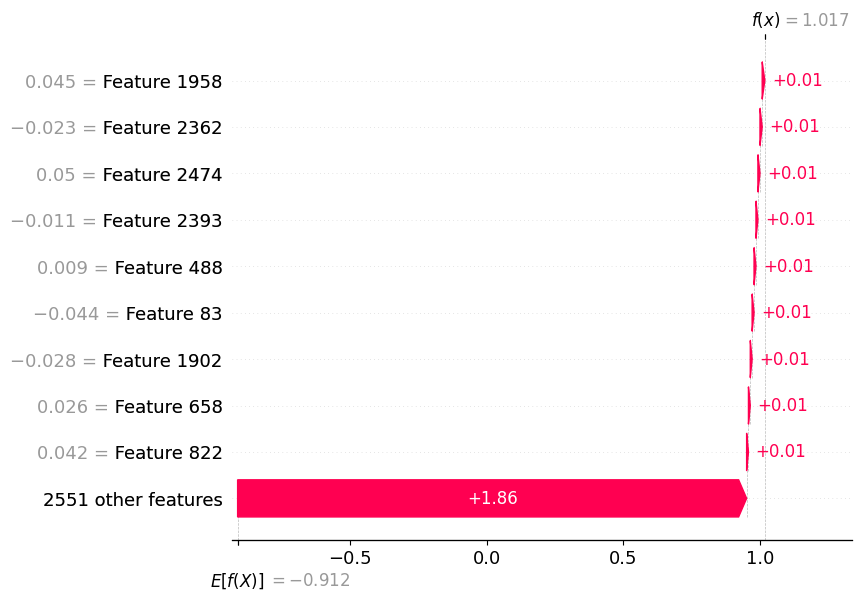

Top global SHAP dimensions for the same skill model:


,feature,mean_abs_shap,coefficient
0,embedding_0023,0.004156,-0.177850
1,embedding_0270,0.003997,0.225092
2,embedding_0083,0.003698,-0.214394
3,embedding_1958,0.003204,0.271769
4,embedding_0426,0.003032,-0.226191
5,embedding_0022,0.003019,-0.230693
6,embedding_0070,0.002854,-0.188157
7,embedding_1029,0.002746,-0.171603
8,embedding_0052,0.002745,-0.206289
9,embedding_0629,0.002693,-0.202828


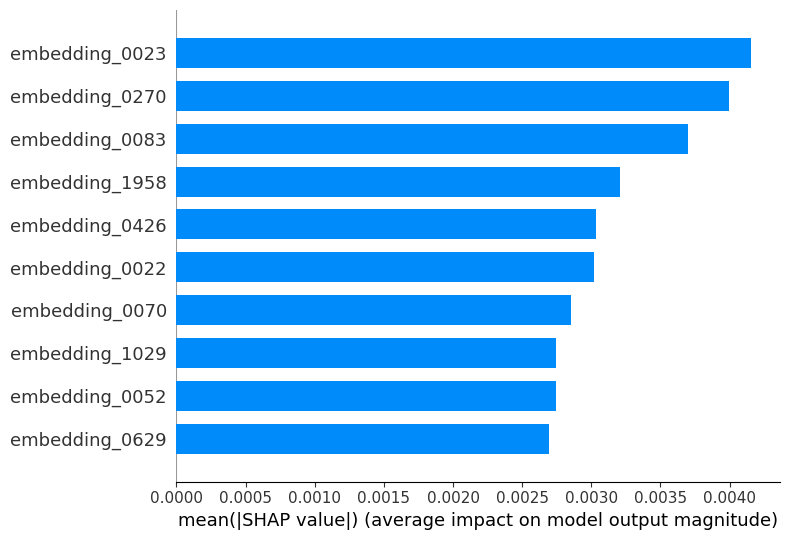

In [15]:
import sys

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP is not installed in the active notebook kernel. Install it in that kernel, for example with `pip install shap`, then rerun this cell. "
        f"Current kernel executable: {sys.executable}"
    ) from exc

best_artifact = artifacts[best_key]
thresholds_df = best_artifact["thresholds_df"].reset_index(drop=True)
frames_best = best_artifact["frames"]
X_train_best = best_artifact["X_train"]
X_test_best = best_artifact["X_test"]
test_proba_best = best_artifact["test_proba"]
fitted_models_best = best_artifact["fitted_models"]
fitted_mask_best = best_artifact["fitted_mask"]

feature_names = [f"embedding_{i:04d}" for i in range(X_train_best.shape[1])]
thresholds = thresholds_df["threshold"].to_numpy(dtype=np.float32)
valid_skill_idx = np.where(fitted_mask_best)[0]

if len(valid_skill_idx) == 0:
    raise RuntimeError("No fitted skill models are available for SHAP explanation.")

test_margin = test_proba_best[:, valid_skill_idx] - thresholds[valid_skill_idx][np.newaxis, :]
best_flat_idx = int(np.argmax(test_margin))
test_row_pos, skill_pos = np.unravel_index(best_flat_idx, test_margin.shape)
test_row_idx = int(test_row_pos)
skill_idx = int(valid_skill_idx[skill_pos])

skill_name = skill_names[skill_idx]
skill_model = fitted_models_best[skill_idx]
skill_threshold = float(thresholds[skill_idx])
skill_probability = float(test_proba_best[test_row_idx, skill_idx])
background_size = min(50, X_train_best.shape[0])
background = X_train_best[:background_size]

explainer = shap.LinearExplainer(skill_model, background)
single_example = X_test_best[test_row_idx:test_row_idx + 1]
single_explanation = explainer(single_example)

single_values = single_explanation.values[0]
single_features = single_example[0]
coefficients = skill_model.coef_.ravel()
top_local_idx = np.argsort(np.abs(single_values))[-10:][::-1]

local_shap_df = pd.DataFrame({
    "feature": [feature_names[i] for i in top_local_idx],
    "feature_value": single_features[top_local_idx],
    "shap_value": single_values[top_local_idx],
    "coefficient": coefficients[top_local_idx],
})

test_row = frames_best["test"].iloc[test_row_idx]
predicted_skills = artifacts[best_key]["predictions_df"].iloc[test_row_idx]["predicted_skills"]
actual_skills = artifacts[best_key]["predictions_df"].iloc[test_row_idx]["actual_skills"]

print("SHAP explanation target:")
print(f"  dataset variant: {best_row['dataset_variant']}")
print(f"  threshold type: {best_row['threshold_type']}")
print(f"  explained test row: {test_row_idx}")
print(f"  title: {test_row['display_title']}")
print(f"  explained skill: {skill_name}")
print(f"  predicted probability: {skill_probability:.6f}")
print(f"  decision threshold: {skill_threshold:.6f}")
print(f"  actual skills: {actual_skills}")
print(f"  predicted skills: {predicted_skills}")
print()
print("Top local SHAP contributors for this skill prediction:")
display(local_shap_df)

shap.plots.waterfall(single_explanation[0], max_display=10)
plt.show()

global_sample_size = min(30, X_test_best.shape[0])
global_explanations = explainer(X_test_best[:global_sample_size])
mean_abs_shap = np.abs(global_explanations.values).mean(axis=0)
top_global_idx = np.argsort(mean_abs_shap)[-10:][::-1]

global_shap_df = pd.DataFrame({
    "feature": [feature_names[i] for i in top_global_idx],
    "mean_abs_shap": mean_abs_shap[top_global_idx],
    "coefficient": coefficients[top_global_idx],
})

print("Top global SHAP dimensions for the same skill model:")
display(global_shap_df)

shap.summary_plot(
    global_explanations.values,
    features=X_test_best[:global_sample_size],
    feature_names=feature_names,
    plot_type="bar",
    max_display=10,
    show=False,
)
plt.tight_layout()
plt.show()


## Final ACC Skills Gap Table

This section refits the selected final ACC model on the full labeled dataset (`train + val + test`) and scores all ACC jobs and ACC courses.

It then creates a rule-based table for high-demand skills using:
- predicted job demand across all ACC jobs
- predicted curriculum coverage across all ACC courses
- whether any covering course is compulsory for the NUS Accountancy major


In [16]:
COMPULSORY_ACC_MODULE_CODES = {
    "ACC1701",
    "ACC2706",
    "ACC2707",
    "ACC2708",
    "ACC2709",
    "ACC2727",
    "ACC3701",
    "ACC3702",
    "ACC3703",
    "ACC3704",
    "ACC3705",
    "ACC3706",
    "ACC3707",
    "ACC3727",
}
HIGH_DEMAND_THRESHOLD_PERCENT = 10.0


def canonical_accountancy_module_code(module_code):
    code = str(module_code).strip().upper()
    if code in COMPULSORY_ACC_MODULE_CODES:
        return code
    if code and code[-1].isalpha() and code[:-1] in COMPULSORY_ACC_MODULE_CODES:
        return code[:-1]
    return code


best_variant_name = str(best_row["dataset_variant"])
best_threshold_type = str(best_row["threshold_type"])
best_artifact = artifacts[best_key]

if "jobs_all_df" not in globals():
    jobs_all_df = pd.concat([
        jobs_train_df.assign(split="train"),
        jobs_val_df.assign(split="val"),
        jobs_test_df.assign(split="test"),
    ], ignore_index=True)

if "courses_all_df" not in globals():
    courses_all_df = pd.concat([
        courses_train_df.assign(split="train"),
        courses_val_df.assign(split="val"),
        courses_test_df.assign(split="test"),
    ], ignore_index=True)

if best_variant_name == "jobs_only":
    full_fit_df = jobs_all_df.reset_index(drop=True).copy()
else:
    full_fit_df = pd.concat([jobs_all_df, courses_all_df], ignore_index=True)

X_full_fit = np.vstack(full_fit_df["embedding"].to_numpy()).astype(np.float32)
Y_full_fit = build_indicator_matrix(full_fit_df["actual_skill_lists"].tolist(), skill_names)
X_jobs_all = np.vstack(jobs_all_df["embedding"].to_numpy()).astype(np.float32)
X_courses_all = np.vstack(courses_all_df["embedding"].to_numpy()).astype(np.float32)

jobs_full_proba = np.zeros((X_jobs_all.shape[0], len(skill_names)), dtype=np.float32)
courses_full_proba = np.zeros((X_courses_all.shape[0], len(skill_names)), dtype=np.float32)
full_fitted_mask = np.zeros(len(skill_names), dtype=bool)
full_skipped_skills = []

for j, skill_name in enumerate(skill_names):
    y_full_j = Y_full_fit[:, j]

    if len(np.unique(y_full_j)) < 2:
        full_skipped_skills.append(skill_name)
        continue

    model = LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    )
    model.fit(X_full_fit, y_full_j)

    jobs_full_proba[:, j] = model.predict_proba(X_jobs_all)[:, 1]
    courses_full_proba[:, j] = model.predict_proba(X_courses_all)[:, 1]
    full_fitted_mask[j] = True

if best_threshold_type == "global":
    selected_thresholds = np.full(len(skill_names), float(best_row["global_threshold"]), dtype=np.float32)
else:
    selected_thresholds = best_artifact["thresholds_df"]["threshold"].to_numpy(dtype=np.float32)

jobs_full_pred = (jobs_full_proba >= selected_thresholds[np.newaxis, :]).astype(np.uint8)
courses_full_pred = (courses_full_proba >= selected_thresholds[np.newaxis, :]).astype(np.uint8)

job_skill_counts = jobs_full_pred.sum(axis=0).astype(int)
course_skill_counts = courses_full_pred.sum(axis=0).astype(int)
job_denominator = max(len(jobs_all_df), 1)
course_codes = courses_all_df["entity_id"].astype(str).tolist()
course_titles = courses_all_df["display_title"].astype(str).tolist()

gap_rows = []
for j, skill_name in enumerate(skill_names):
    job_demand_percent = 100.0 * job_skill_counts[j] / job_denominator
    job_demand_label = "High" if job_demand_percent >= HIGH_DEMAND_THRESHOLD_PERCENT else "Low"

    course_idx = np.where(courses_full_pred[:, j] == 1)[0]
    compulsory_course_labels = []
    elective_course_labels = []

    for idx in course_idx:
        course_code = course_codes[idx]
        course_title = course_titles[idx]
        course_label = f"{course_code}: {course_title}"
        if canonical_accountancy_module_code(course_code) in COMPULSORY_ACC_MODULE_CODES:
            compulsory_course_labels.append(course_label)
        else:
            elective_course_labels.append(course_label)

    taught_in_any_course = len(course_idx) > 0
    taught_in_compulsory_course = len(compulsory_course_labels) > 0

    if taught_in_compulsory_course:
        curriculum_coverage = "Strong"
    elif taught_in_any_course:
        curriculum_coverage = "Weak"
    else:
        curriculum_coverage = "Very weak"

    if job_demand_label == "High" and taught_in_compulsory_course:
        gap_interpretation = "Well covered"
    elif job_demand_label == "High" and taught_in_any_course:
        gap_interpretation = "Important gap - High demand skill but course not compulsory"
    elif job_demand_label == "High":
        gap_interpretation = "Critical gap - High demand skill not taught in ACC courses"
    elif taught_in_compulsory_course:
        gap_interpretation = "Compulsory coverage for lower-demand skill"
    elif taught_in_any_course:
        gap_interpretation = "Elective coverage for lower-demand skill"
    else:
        gap_interpretation = "Low demand and limited coverage"

    gap_rows.append({
        "skill_name": skill_name,
        "job_demand_percent": float(job_demand_percent),
        "job_demand": job_demand_label,
        "job_postings_with_skill": int(job_skill_counts[j]),
        "taught_in_any_course": "Yes" if taught_in_any_course else "No",
        "taught_in_compulsory_course": "Yes" if taught_in_compulsory_course else "No",
        "courses_covering_skill": int(course_skill_counts[j]),
        "curriculum_coverage": curriculum_coverage,
        "gap_interpretation": gap_interpretation,
        "compulsory_courses": " | ".join(compulsory_course_labels[:5]),
        "elective_courses": " | ".join(elective_course_labels[:5]),
    })

full_model_gap_table_df = pd.DataFrame(gap_rows).sort_values(
    by=["job_demand", "job_demand_percent", "curriculum_coverage", "skill_name"],
    ascending=[False, False, True, True],
).reset_index(drop=True)

high_demand_gap_table_df = full_model_gap_table_df.loc[
    full_model_gap_table_df["job_demand"] == "High"
].reset_index(drop=True)

final_model_refit_summary_df = pd.DataFrame({
    "selected_dataset_variant": [best_variant_name],
    "selected_threshold_type": [best_threshold_type],
    "full_fit_rows": [len(full_fit_df)],
    "jobs_scored": [len(jobs_all_df)],
    "courses_scored": [len(courses_all_df)],
    "fitted_skills_after_refit": [int(full_fitted_mask.sum())],
    "skipped_skills_after_refit": [len(full_skipped_skills)],
    "high_demand_threshold_percent": [HIGH_DEMAND_THRESHOLD_PERCENT],
})

print("Final ACC model refit summary:")
display(final_model_refit_summary_df)
print()
print("High-demand ACC skills gap table:")
display(high_demand_gap_table_df[[
    "skill_name",
    "job_demand_percent",
    "job_demand",
    "taught_in_any_course",
    "taught_in_compulsory_course",
    "curriculum_coverage",
    "gap_interpretation",
    "compulsory_courses",
    "elective_courses",
]])


Final ACC model refit summary:


,selected_dataset_variant,selected_threshold_type,full_fit_rows,jobs_scored,courses_scored,fitted_skills_after_refit,skipped_skills_after_refit,high_demand_threshold_percent
0,jobs_only,global,98,98,63,54,175,10.0



High-demand ACC skills gap table:


,skill_name,job_demand_percent,job_demand,taught_in_any_course,taught_in_compulsory_course,curriculum_coverage,gap_interpretation,compulsory_courses,elective_courses
0,Accounting Standards,69.387755,High,Yes,No,Weak,Important gap - High demand skill but course n...,,ACC2712: Financial Accounting | ACC3714: Accou...
1,Financial Transactions,66.326531,High,No,No,Very weak,Critical gap - High demand skill not taught in...,,
2,Transactional Accounting,66.326531,High,No,No,Very weak,Critical gap - High demand skill not taught in...,,
3,Financial Closing,61.224490,High,No,No,Very weak,Critical gap - High demand skill not taught in...,,
4,Financial Reporting,58.163265,High,Yes,Yes,Strong,Well covered,ACC3704: Advanced Corporate Accounting and Rep...,ACC1701XB: Accounting for Decision Makers | AC...
5,Financial Administration,44.897959,High,No,No,Very weak,Critical gap - High demand skill not taught in...,,
6,Tax Compliance,34.693878,High,Yes,No,Weak,Important gap - High demand skill but course n...,,ACC4611: Advanced Taxation | ACC4711: Advanced...
7,Internal Controls,29.591837,High,Yes,Yes,Strong,Well covered,"ACC3706: Governance, Risk Management and Susta...",ACC3711: Managerial Planning and Control | ACC...
8,Audit Compliance,25.510204,High,No,No,Very weak,Critical gap - High demand skill not taught in...,,
9,Accounting and Tax Systems,22.448980,High,No,No,Very weak,Critical gap - High demand skill not taught in...,,


## Data Quality Diagnostics

Before changing the model family, it is useful to inspect whether the labels and dataset construction are limiting performance.

The cells below audit five areas:
- overall skill coverage and rare-skill support
- skills that are out of vocabulary relative to the skill embedding file
- title-level label consistency and nearest-neighbor disagreement between similar jobs
- heuristic candidates for missing skills in `extracted_skills`
- whether course labels look aligned enough with job labels to justify mixing them

These diagnostics are heuristic, so they should be treated as quality-review tools rather than ground-truth error detectors.


In [17]:
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

best_variant_name = str(best_row["dataset_variant"])
best_artifact = artifacts[best_key]
best_thresholds_df = best_artifact["thresholds_df"].reset_index(drop=True)
best_fitted_mask = np.asarray(best_artifact["fitted_mask"], dtype=bool)

jobs_all_df = pd.concat([
    jobs_train_df.assign(split="train"),
    jobs_val_df.assign(split="val"),
    jobs_test_df.assign(split="test"),
], ignore_index=True)

courses_all_df = pd.concat([
    courses_train_df.assign(split="train"),
    courses_val_df.assign(split="val"),
    courses_test_df.assign(split="test"),
], ignore_index=True)

def flatten_skill_lists(skill_lists):
    return [skill for skills in skill_lists for skill in skills]

def canonical_skill_signature(skills):
    return " | ".join(sorted(set(skills)))

def jaccard_score(left_skills, right_skills):
    left_set = set(left_skills)
    right_set = set(right_skills)
    union = left_set | right_set
    if not union:
        return 1.0
    return len(left_set & right_set) / len(union)

def support_frame(df, prefix):
    indicator = build_indicator_matrix(df["actual_skill_lists"].tolist(), skill_names)
    return pd.DataFrame({
        "skill_name": skill_names,
        f"{prefix}_support": indicator.sum(axis=0).astype(int),
    })

support_df = pd.DataFrame({"skill_name": skill_names})
for prefix, frame in [
    ("jobs_train", jobs_train_df),
    ("jobs_val", jobs_val_df),
    ("jobs_test", jobs_test_df),
    ("courses_train", courses_train_df),
    ("courses_val", courses_val_df),
    ("courses_test", courses_test_df),
]:
    support_df = support_df.merge(support_frame(frame, prefix), on="skill_name", how="left")

support_cols = [col for col in support_df.columns if col.endswith("_support")]
support_df[support_cols] = support_df[support_cols].fillna(0).astype(int)
support_df["jobs_total_support"] = support_df[["jobs_train_support", "jobs_val_support", "jobs_test_support"]].sum(axis=1)
support_df["courses_total_support"] = support_df[["courses_train_support", "courses_val_support", "courses_test_support"]].sum(axis=1)
support_df["combined_train_support"] = support_df["jobs_train_support"] + support_df["courses_train_support"]
support_df["best_model_train_support"] = np.where(
    best_variant_name == "jobs_only",
    support_df["jobs_train_support"],
    support_df["combined_train_support"],
)
support_df["best_model_was_fitted"] = best_fitted_mask
support_df["best_model_status"] = np.where(best_fitted_mask, "fitted", "skipped")
support_df["best_model_threshold"] = best_thresholds_df["threshold"].astype(float).to_numpy()

job_labels_audit_df = job_labels.copy()
course_labels_audit_df = course_labels.copy()
job_labels_audit_df["parsed_skill_lists"] = job_labels_audit_df["extracted_skills"].apply(parse_skill_list)
course_labels_audit_df["parsed_skill_lists"] = course_labels_audit_df["extracted_skills"].apply(parse_skill_list)

known_skill_set = set(skill_names)
job_oov_skills = sorted(set(flatten_skill_lists(job_labels_audit_df["parsed_skill_lists"])) - known_skill_set)
course_oov_skills = sorted(set(flatten_skill_lists(course_labels_audit_df["parsed_skill_lists"])) - known_skill_set)

summary_df = pd.DataFrame({
    "best_model_variant": [best_variant_name],
    "best_threshold_type": [str(best_row["threshold_type"])],
    "total_skills": [len(skill_names)],
    "best_model_fitted_skills": [int(best_fitted_mask.sum())],
    "best_model_skipped_skills": [int((~best_fitted_mask).sum())],
    "skills_with_zero_job_train_support": [int((support_df["jobs_train_support"] == 0).sum())],
    "skills_with_zero_combined_train_support": [int((support_df["combined_train_support"] == 0).sum())],
    "rare_skills_best_model_train_support_le_2": [int((support_df["best_model_train_support"] <= 2).sum())],
    "job_oov_skills": [len(job_oov_skills)],
    "course_oov_skills": [len(course_oov_skills)],
})

rare_skills_df = support_df.loc[
    support_df["best_model_train_support"] <= 2,
    [
        "skill_name",
        "jobs_train_support",
        "courses_train_support",
        "combined_train_support",
        "best_model_train_support",
        "best_model_status",
        "best_model_threshold",
    ],
].sort_values(
    by=["best_model_train_support", "combined_train_support", "skill_name"],
    ascending=[True, True, True],
).reset_index(drop=True)

print("Data coverage summary:")
display(summary_df)
print()
print("Rare-skill audit for the best model (train support <= 2):")
display(rare_skills_df.head(30))
print()
print(f"Job OOV skills relative to acc_skills_embeddings.jsonl: {len(job_oov_skills)}")
print(job_oov_skills[:25])
print()
print(f"Course OOV skills relative to acc_skills_embeddings.jsonl: {len(course_oov_skills)}")
print(course_oov_skills[:25])


Data coverage summary:


,best_model_variant,best_threshold_type,total_skills,best_model_fitted_skills,best_model_skipped_skills,skills_with_zero_job_train_support,skills_with_zero_combined_train_support,rare_skills_best_model_train_support_le_2,job_oov_skills,course_oov_skills
0,jobs_only,global,229,52,177,177,155,200,0,0



Rare-skill audit for the best model (train support <= 2):


,skill_name,jobs_train_support,courses_train_support,combined_train_support,best_model_train_support,best_model_status,best_model_threshold
0,Account Management,0,0,0,0,skipped,0.50558
1,Analytics and Computational Modelling,0,0,0,0,skipped,0.50558
2,Asset and Liability Management,0,0,0,0,skipped,0.50558
3,Attribution Analysis,0,0,0,0,skipped,0.50558
4,Audit Frameworks,0,0,0,0,skipped,0.50558
5,Auditor Independence,0,0,0,0,skipped,0.50558
6,Behavioural Finance,0,0,0,0,skipped,0.50558
7,Benchmarking,0,0,0,0,skipped,0.50558
8,Block Trading,0,0,0,0,skipped,0.50558
9,Book Building,0,0,0,0,skipped,0.50558



Job OOV skills relative to acc_skills_embeddings.jsonl: 0
[]

Course OOV skills relative to acc_skills_embeddings.jsonl: 0
[]


In [18]:
job_labels_audit_df["normalized_title"] = (
    job_labels_audit_df["title"].fillna(job_labels_audit_df["raw_title"]).fillna("")
    .str.lower()
    .str.strip()
)
job_labels_audit_df["skill_signature"] = job_labels_audit_df["parsed_skill_lists"].apply(canonical_skill_signature)

title_conflicts_df = (
    job_labels_audit_df.groupby("normalized_title")
    .agg(
        num_rows=("uuid", "size"),
        distinct_skill_signatures=("skill_signature", "nunique"),
        sample_title=("title", lambda s: next((str(v) for v in s if pd.notna(v) and str(v).strip()), "")),
    )
    .reset_index()
)

title_conflicts_df = title_conflicts_df.loc[
    (title_conflicts_df["num_rows"] > 1) & (title_conflicts_df["distinct_skill_signatures"] > 1)
].sort_values(
    by=["distinct_skill_signatures", "num_rows", "sample_title"],
    ascending=[False, False, True],
).reset_index(drop=True)

jobs_matrix = np.vstack(jobs_all_df["embedding"].to_numpy()).astype(np.float32)
jobs_similarity = cosine_similarity(jobs_matrix)
np.fill_diagonal(jobs_similarity, -np.inf)
job_skill_sets = jobs_all_df["actual_skill_lists"].apply(lambda skills: set(skills)).tolist()

nearest_neighbor_rows = []
for row_idx in range(len(jobs_all_df)):
    neighbor_idx = int(np.argmax(jobs_similarity[row_idx]))
    left_skills = job_skill_sets[row_idx]
    right_skills = job_skill_sets[neighbor_idx]
    nearest_neighbor_rows.append({
        "split": jobs_all_df.iloc[row_idx]["split"],
        "entity_id": jobs_all_df.iloc[row_idx]["entity_id"],
        "title": jobs_all_df.iloc[row_idx]["display_title"],
        "nearest_neighbor_id": jobs_all_df.iloc[neighbor_idx]["entity_id"],
        "nearest_neighbor_title": jobs_all_df.iloc[neighbor_idx]["display_title"],
        "cosine_similarity": float(jobs_similarity[row_idx, neighbor_idx]),
        "label_jaccard": float(jaccard_score(left_skills, right_skills)),
        "num_shared_skills": int(len(left_skills & right_skills)),
        "num_only_current": int(len(left_skills - right_skills)),
        "num_only_neighbor": int(len(right_skills - left_skills)),
        "current_skills": " | ".join(sorted(left_skills)),
        "neighbor_skills": " | ".join(sorted(right_skills)),
    })

nearest_neighbor_df = pd.DataFrame(nearest_neighbor_rows)
similarity_threshold = float(nearest_neighbor_df["cosine_similarity"].quantile(0.75))
high_similarity_disagreement_df = nearest_neighbor_df.loc[
    nearest_neighbor_df["cosine_similarity"] >= similarity_threshold
].sort_values(
    by=["label_jaccard", "cosine_similarity"],
    ascending=[True, False],
).reset_index(drop=True)

consistency_summary_df = pd.DataFrame({
    "same_title_conflict_groups": [len(title_conflicts_df)],
    "median_nearest_job_cosine_similarity": [nearest_neighbor_df["cosine_similarity"].median()],
    "median_nearest_job_label_jaccard": [nearest_neighbor_df["label_jaccard"].median()],
    "high_similarity_threshold": [similarity_threshold],
    "high_similarity_jobs_with_label_jaccard_below_0_25": [
        int(((nearest_neighbor_df["cosine_similarity"] >= similarity_threshold) & (nearest_neighbor_df["label_jaccard"] < 0.25)).sum())
    ],
})

print("Label consistency summary:")
display(consistency_summary_df)
print()
print("Repeated job titles with conflicting skill signatures:")
display(title_conflicts_df.head(20))
print()
print("Most suspicious similar-job disagreements (high cosine similarity, low label overlap):")
display(high_similarity_disagreement_df.head(20))


Label consistency summary:


,same_title_conflict_groups,median_nearest_job_cosine_similarity,median_nearest_job_label_jaccard,high_similarity_threshold,high_similarity_jobs_with_label_jaccard_below_0_25
0,6,0.897267,0.522727,0.983182,0



Repeated job titles with conflicting skill signatures:


,normalized_title,num_rows,distinct_skill_signatures,sample_title
0,accounts assistant,10,9,ACCOUNTS ASSISTANT
1,audit associate,6,6,Audit Associate
2,accounts executive,3,3,Accounts Executive
3,6 months accounts payable executive #njn,2,2,6 Months Accounts Payable Executive #NJN
4,account executive,2,2,account executive
5,audit assistant,2,2,audit assistant



Most suspicious similar-job disagreements (high cosine similarity, low label overlap):


,split,entity_id,title,nearest_neighbor_id,nearest_neighbor_title,cosine_similarity,label_jaccard,num_shared_skills,num_only_current,num_only_neighbor,current_skills,neighbor_skills
0,val,8b27d8d993bf21838b89a9d8e2e1ada8,AB03 - Junior Audit Officer,961cd053a613474af5899f43afd7310c,AB03 - Junior Audit Executive,0.991978,0.250000,1,3,0,Auditing and Assurance Standards | Engagement ...,Engagement Execution
1,train,961cd053a613474af5899f43afd7310c,AB03 - Junior Audit Executive,54e961ef0600ff104afd35667ad63e63,AB03 - Audit Associate – Junior Level,1.000001,0.500000,1,0,1,Engagement Execution,Engagement Execution | Internal Controls
2,test,54e961ef0600ff104afd35667ad63e63,AB03 - Audit Associate – Junior Level,961cd053a613474af5899f43afd7310c,AB03 - Junior Audit Executive,1.000001,0.500000,1,1,0,Engagement Execution | Internal Controls,Engagement Execution
3,train,0f9c0580f8f467d091fad75f86fef2b0,6 Months Accounts Payable Executive #NJN,b7690507c7f89a17c14378392f7126a6,6 Months Accounts Payable Executive #NJN,1.000001,0.545455,6,1,4,Cash Flow Reporting | Financial Administration...,Audit Compliance | Cash Flow Reporting | Finan...
4,val,b7690507c7f89a17c14378392f7126a6,6 Months Accounts Payable Executive #NJN,0f9c0580f8f467d091fad75f86fef2b0,6 Months Accounts Payable Executive #NJN,1.000001,0.545455,6,4,1,Audit Compliance | Cash Flow Reporting | Finan...,Cash Flow Reporting | Financial Administration...
5,train,da824c9b2923bf8768966ce83cafa56e,6723 - Accountant [ERP System | Exp in Audit S...,958a0121b7d582a9092fad234005e96c,6723 - Finance Business Partner (AR/AP) – Offs...,1.000001,0.941176,16,0,1,Accounting Standards | Accounting and Tax Syst...,Accounting Standards | Accounting and Tax Syst...
6,train,958a0121b7d582a9092fad234005e96c,6723 - Finance Business Partner (AR/AP) – Offs...,da824c9b2923bf8768966ce83cafa56e,6723 - Accountant [ERP System | Exp in Audit S...,1.000001,0.941176,16,1,0,Accounting Standards | Accounting and Tax Syst...,Accounting Standards | Accounting and Tax Syst...
7,val,e65709857c2a46f0299c539c4ef004e9,Accounts Assistant (5 days / Marine Parade),2b4b9444b111a864a90de840ec0a6272,Accounts Assistant (5 days),1.000002,1.000000,5,0,0,Accounting Standards | Financial Administratio...,Accounting Standards | Financial Administratio...
8,test,2b4b9444b111a864a90de840ec0a6272,Accounts Assistant (5 days),e65709857c2a46f0299c539c4ef004e9,Accounts Assistant (5 days / Marine Parade),1.000002,1.000000,5,0,0,Accounting Standards | Financial Administratio...,Accounting Standards | Financial Administratio...
9,train,68f8be1da27944cb292ef23f0825dd88,Senior Audit Associate/Supervisor,a36a59751eacae22922dfbc1568dcde8,Audit Associate/Senior,1.000002,1.000000,5,0,0,Audit Compliance | Auditing and Assurance Stan...,Audit Compliance | Auditing and Assurance Stan...


In [19]:
neighbor_top_k = min(5, len(jobs_all_df) - 1)
missing_label_candidate_rows = []

for row_idx in range(len(jobs_all_df)):
    nearest_indices = np.argsort(jobs_similarity[row_idx])[::-1][:neighbor_top_k]
    current_skills = job_skill_sets[row_idx]
    skill_votes = Counter()
    skill_similarity_sum = Counter()
    skill_supporting_titles = {}

    for neighbor_idx in nearest_indices:
        neighbor_similarity = float(jobs_similarity[row_idx, neighbor_idx])
        for skill in job_skill_sets[neighbor_idx]:
            if skill in current_skills:
                continue
            skill_votes[skill] += 1
            skill_similarity_sum[skill] += neighbor_similarity
            skill_supporting_titles.setdefault(skill, []).append(str(jobs_all_df.iloc[neighbor_idx]["display_title"]))

    for skill_name, votes in skill_votes.items():
        if votes < 3:
            continue
        avg_similarity = skill_similarity_sum[skill_name] / votes
        missing_label_candidate_rows.append({
            "split": jobs_all_df.iloc[row_idx]["split"],
            "entity_id": jobs_all_df.iloc[row_idx]["entity_id"],
            "title": jobs_all_df.iloc[row_idx]["display_title"],
            "candidate_missing_skill": skill_name,
            "neighbor_votes": int(votes),
            "avg_neighbor_similarity": float(avg_similarity),
            "current_num_skills": int(len(current_skills)),
            "current_skills": " | ".join(sorted(current_skills)),
            "supporting_neighbor_titles": " || ".join(skill_supporting_titles[skill_name][:3]),
        })

missing_label_candidates_df = pd.DataFrame(missing_label_candidate_rows)
if not missing_label_candidates_df.empty:
    missing_label_candidates_df = missing_label_candidates_df.sort_values(
        by=["neighbor_votes", "avg_neighbor_similarity", "title", "candidate_missing_skill"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)

print("Heuristic candidates for missing skills in extracted_skills:")
print("These are skills absent from a job label but present in at least 3 of its 5 nearest job neighbors.")
display(missing_label_candidates_df.head(25))


Heuristic candidates for missing skills in extracted_skills:
These are skills absent from a job label but present in at least 3 of its 5 nearest job neighbors.


,split,entity_id,title,candidate_missing_skill,neighbor_votes,avg_neighbor_similarity,current_num_skills,current_skills,supporting_neighbor_titles
0,train,147f78025c8a96513230ed119e5589e7,Account assistant (Intern),Financial Reporting,5,0.914248,4,Accounting Standards | Financial Closing | Fin...,Accounts assistant || Accounts Executive || AC...
1,train,39f98fd5891333f6406559c1d32f6a47,Finance and Admin Executive,Financial Transactions,5,0.901672,7,Accounting Standards | Financial Administratio...,"Finance Executive || Executive, Accounts and F..."
2,train,39f98fd5891333f6406559c1d32f6a47,Finance and Admin Executive,Transactional Accounting,5,0.901672,7,Accounting Standards | Financial Administratio...,"Finance Executive || Executive, Accounts and F..."
3,val,9647da6b32188a8a77b7c7cdcbe31849,Accounts Assistant,Accounting Standards,5,0.880656,4,Accounting and Tax Systems | Financial Closing...,Accounts Executive || ACCOUNTS ASSISTANT || Ac...
4,train,1cee73ac14a50cf337b4d18105dff50a,"Executive, Accounts and Finance",Financial Reporting,5,0.880447,6,Accounting Standards | Financial Administratio...,Finance and Admin Executive || Junior Accounta...
5,train,1819f59d19cd2a1b4ff530ca6b770801,Auditor,Financial Reporting,5,0.876261,8,Accounting Standards | Auditing and Assurance ...,Audit Assistant || Audit Associate/Senior || S...
6,train,04c1eb32c3faca0e46e06f8602f7f443,Audit Assistant,Auditing and Assurance Standards,5,0.869811,6,Engagement Completion and Reporting | Engageme...,Auditor || Audit Associate/Senior || Senior Au...
7,val,0158592ac530560f487cbe6e86df8075,Accounts/Admin Assistant,Accounting Standards,5,0.868417,3,Financial Administration | Financial Transacti...,Accounts Executive || Accounts assistant || Ac...
8,val,0158592ac530560f487cbe6e86df8075,Accounts/Admin Assistant,Financial Closing,5,0.868417,3,Financial Administration | Financial Transacti...,Accounts Executive || Accounts assistant || Ac...
9,train,58562e1b4aa7980859ddce108f146036,Accounts & Admin Executive #82058,Transactional Accounting,5,0.864277,6,Accounting Standards | Financial Administratio...,Accounts & Admin Executive #76871 || Accounts ...


In [20]:
alignment_df = support_df[["skill_name", "jobs_train_support", "courses_train_support"]].copy()
alignment_df = alignment_df.loc[(alignment_df["jobs_train_support"] + alignment_df["courses_train_support"]) > 0].copy()
alignment_df["jobs_train_frequency"] = alignment_df["jobs_train_support"] / max(len(jobs_train_df), 1)
alignment_df["courses_train_frequency"] = alignment_df["courses_train_support"] / max(len(courses_train_df), 1)
alignment_df["frequency_gap"] = alignment_df["jobs_train_frequency"] - alignment_df["courses_train_frequency"]
alignment_df["abs_frequency_gap"] = alignment_df["frequency_gap"].abs()

shared_train_skills = int(((alignment_df["jobs_train_support"] > 0) & (alignment_df["courses_train_support"] > 0)).sum())
job_only_train_skills = int(((alignment_df["jobs_train_support"] > 0) & (alignment_df["courses_train_support"] == 0)).sum())
course_only_train_skills = int(((alignment_df["jobs_train_support"] == 0) & (alignment_df["courses_train_support"] > 0)).sum())
frequency_correlation = alignment_df["jobs_train_frequency"].corr(alignment_df["courses_train_frequency"])

jobs_avg_skills = jobs_all_df["actual_skill_lists"].apply(len).mean()
courses_avg_skills = courses_all_df["actual_skill_lists"].apply(len).mean()

courses_matrix = np.vstack(courses_all_df["embedding"].to_numpy()).astype(np.float32)
course_to_job_similarity = cosine_similarity(courses_matrix, jobs_matrix)
best_job_match_idx = course_to_job_similarity.argmax(axis=1)

course_job_alignment_rows = []
for course_idx, job_idx in enumerate(best_job_match_idx):
    course_skills = set(courses_all_df.iloc[course_idx]["actual_skill_lists"])
    job_skills = job_skill_sets[job_idx]
    course_job_alignment_rows.append({
        "course_split": courses_all_df.iloc[course_idx]["split"],
        "course_code": courses_all_df.iloc[course_idx]["entity_id"],
        "course_title": courses_all_df.iloc[course_idx]["display_title"],
        "matched_job_id": jobs_all_df.iloc[job_idx]["entity_id"],
        "matched_job_title": jobs_all_df.iloc[job_idx]["display_title"],
        "cosine_similarity": float(course_to_job_similarity[course_idx, job_idx]),
        "label_jaccard": float(jaccard_score(course_skills, job_skills)),
        "shared_skills": " | ".join(sorted(course_skills & job_skills)),
        "course_only_skills": " | ".join(sorted(course_skills - job_skills)),
        "job_only_skills": " | ".join(sorted(job_skills - course_skills)),
    })

course_job_alignment_df = pd.DataFrame(course_job_alignment_rows).sort_values(
    by=["label_jaccard", "cosine_similarity"],
    ascending=[True, False],
).reset_index(drop=True)

alignment_summary_df = pd.DataFrame({
    "shared_train_skills": [shared_train_skills],
    "job_only_train_skills": [job_only_train_skills],
    "course_only_train_skills": [course_only_train_skills],
    "jobs_vs_courses_train_frequency_corr": [frequency_correlation],
    "avg_skills_per_job_record": [jobs_avg_skills],
    "avg_skills_per_course_record": [courses_avg_skills],
    "median_course_to_nearest_job_cosine": [course_job_alignment_df["cosine_similarity"].median()],
    "median_course_to_nearest_job_label_jaccard": [course_job_alignment_df["label_jaccard"].median()],
})

largest_frequency_gap_df = alignment_df.sort_values(
    by=["abs_frequency_gap", "skill_name"],
    ascending=[False, True],
).reset_index(drop=True)

print("Jobs vs courses alignment summary:")
display(alignment_summary_df)
print()
print("Skills with the largest train-frequency mismatch between jobs and courses:")
display(largest_frequency_gap_df.head(25))
print()
print("Courses whose nearest job neighbor has very low label overlap:")
display(course_job_alignment_df.head(20))


Jobs vs courses alignment summary:


,shared_train_skills,job_only_train_skills,course_only_train_skills,jobs_vs_courses_train_frequency_corr,avg_skills_per_job_record,avg_skills_per_course_record,median_course_to_nearest_job_cosine,median_course_to_nearest_job_label_jaccard
0,19,33,22,0.53416,6.836735,2.428571,0.670055,0.125



Skills with the largest train-frequency mismatch between jobs and courses:


,skill_name,jobs_train_support,courses_train_support,jobs_train_frequency,courses_train_frequency,frequency_gap,abs_frequency_gap
0,Transactional Accounting,33,1,0.559322,0.027027,0.532295,0.532295
1,Financial Closing,31,0,0.525424,0.000000,0.525424,0.525424
2,Financial Transactions,34,2,0.576271,0.054054,0.522217,0.522217
3,Financial Reporting,41,9,0.694915,0.243243,0.451672,0.451672
4,Tax Compliance,25,0,0.423729,0.000000,0.423729,0.423729
5,Accounting Standards,42,11,0.711864,0.297297,0.414567,0.414567
6,Audit Compliance,18,0,0.305085,0.000000,0.305085,0.305085
7,Regulatory Compliance,18,1,0.305085,0.027027,0.278058,0.278058
8,Financial Administration,15,0,0.254237,0.000000,0.254237,0.254237
9,Engagement Execution,14,0,0.237288,0.000000,0.237288,0.237288



Courses whose nearest job neighbor has very low label overlap:


,course_split,course_code,course_title,matched_job_id,matched_job_title,cosine_similarity,label_jaccard,shared_skills,course_only_skills,job_only_skills
0,val,ACC4714,Advanced and Sustainability Assurance,a36a59751eacae22922dfbc1568dcde8,Audit Associate/Senior,0.729057,0.0,,Sustainability Assurance,Audit Compliance | Auditing and Assurance Stan...
1,train,ACC4761A,Seminars in Accounting: Internal Audit,04c1eb32c3faca0e46e06f8602f7f443,Audit Assistant,0.688501,0.0,,Governance,Engagement Completion and Reporting | Engageme...
2,train,ACC4712,Forensic Accounting,68f8be1da27944cb292ef23f0825dd88,Senior Audit Associate/Supervisor,0.670896,0.0,,Big Data Analytics | Digital Forensics | Foren...,Audit Compliance | Auditing and Assurance Stan...
3,train,ACC4613,Forensic Accounting,68f8be1da27944cb292ef23f0825dd88,Senior Audit Associate/Supervisor,0.670134,0.0,,Digital Forensics | Forensic Data Analytics,Audit Compliance | Auditing and Assurance Stan...
4,test,ACC4761H,Sem. in Acctg: Accounting & Business Analysis ...,e65709857c2a46f0299c539c4ef004e9,Accounts Assistant (5 days / Marine Parade),0.668700,0.0,,Financial Analysis,Accounting Standards | Financial Administratio...
5,train,ACC4612K,Sem. in Acctg: Accounting & Business Analysis ...,e65709857c2a46f0299c539c4ef004e9,Accounts Assistant (5 days / Marine Parade),0.660311,0.0,,Business Negotiation | Capital Management,Accounting Standards | Financial Administratio...
6,train,ACC2706,Managerial Accounting,39f98fd5891333f6406559c1d32f6a47,Finance and Admin Executive,0.655060,0.0,,Management Decision Making,Accounting Standards | Financial Administratio...
7,val,ACC4761C,Seminars in Accounting: Advanced Accounting Th...,68f8be1da27944cb292ef23f0825dd88,Senior Audit Associate/Supervisor,0.640811,0.0,,Valuation | Valuation Research and Analysis,Audit Compliance | Auditing and Assurance Stan...
8,test,ACC4612D,SIA: Advanced Accounting Theory,68f8be1da27944cb292ef23f0825dd88,Senior Audit Associate/Supervisor,0.640811,0.0,,Valuation | Valuation Research and Analysis,Audit Compliance | Auditing and Assurance Stan...
9,train,ACC3706,"Governance, Risk Management and Sustainability",68f8be1da27944cb292ef23f0825dd88,Senior Audit Associate/Supervisor,0.638032,0.0,,Accounting Standards | Corporate Governance | ...,Audit Compliance | Auditing and Assurance Stan...


## Summary

This notebook now reads top to bottom as one clean benchmark:
- load data
- prepare supervised labels
- define the experiment variants
- train the OVR models on the train split
- tune thresholds and choose the final configuration on validation
- report the locked test result only for the selected configuration
- refit the selected ACC model on the full labeled dataset to build the final skills gap table
- inspect one prediction with SHAP for interpretability

In practice, the global-threshold OVR variant is usually the stronger baseline here, while the skill-specific-threshold version tends to overfit because the validation set is small and many skills are rare.

The SHAP example supports that best `jobs_only + global` configuration: it explains a test prediction for `Group Accounting and Consolidation` on the job `AB03 - Accountant`, where the predicted probability (`0.734447`) is above the learned decision threshold (`0.505580`) and the skill is also present in the ground-truth label list.

That gives us a concrete interpretability example for a correct positive prediction, although the explanation is expressed in terms of embedding dimensions rather than human-readable words.

### Caveats and Limitations
- This benchmark assumes the CSV `extracted_skills` labels are the ground truth.
- Many skills are rare, so the model learns much better for common skills than rare ones.
- OVR cannot train a classifier for a skill if the train split does not contain both positive and negative examples for that skill.
- Micro-F1 is driven more by common skills, so it can look stronger than macro-F1.
- The skill-specific-threshold variant is more flexible, but it can overfit when the validation set is small.
- SHAP is useful here because each skill classifier is linear, but the explanations operate on embedding dimensions, so they are faithful to the model without being directly semantic.
- One course, `ACC4761E`, is excluded because it currently has no labeled `extracted_skills` value.
